=== PART 1: TITANIC SURVIVAL PREDICTION (LOGISTIC REGRESSION) ===

Confusion Matrix:
[[90 15]
 [19 55]]

Accuracy Performance Metrics:
Model Score (Accuracy): 0.8101

=== PART 2: HOUSE PRICE PREDICTION (LINEAR REGRESSION) ===

Mean Squared Error (MSE): 24.2911
R² (Coefficient of Determination) Score: 0.6688


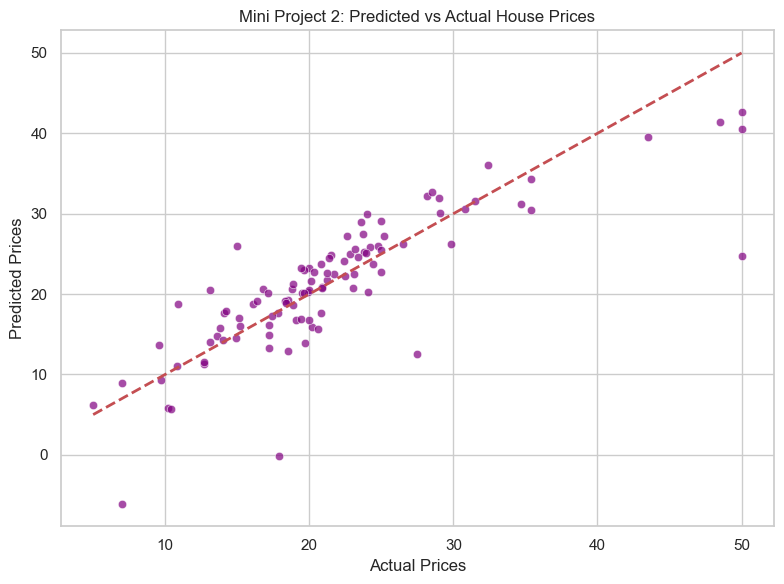


[SUCCESS] Week 2 work completed 


In [4]:
# =====================================================================
# MACHINE LEARNING & AI - WEEK 2 SUPERVISED LEARNING
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
# FIXED IMPORT LINE BELOW:
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report

# ---------------------------------------------------------------------
# PART 1: ASSIGNMENT 2 - LOGISTIC REGRESSION ON TITANIC DATASET
# ---------------------------------------------------------------------
print("=== PART 1: TITANIC SURVIVAL PREDICTION (LOGISTIC REGRESSION) ===")

# 1. Load and quickly prepare Titanic data
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_titanic = pd.read_csv(titanic_url)
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())
df_titanic['Embarked'] = df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0])

# Encode categorical values
df_titanic['Sex'] = df_titanic['Sex'].map({'male': 0, 'female': 1})
df_titanic = pd.get_dummies(df_titanic, columns=['Embarked'], drop_first=True)

# Select features for survival prediction
X_titanic = df_titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']]
y_titanic = df_titanic['Survived']

# Train/Test Split (80% Train, 20% Test)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

# Train Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_t, y_train_t)

# Evaluate Classification Performance
y_pred_t = log_reg.predict(X_test_t)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_t, y_pred_t))
print("\nAccuracy Performance Metrics:")
print(f"Model Score (Accuracy): {log_reg.score(X_test_t, y_test_t):.4f}")


# ---------------------------------------------------------------------
# PART 2: MINI PROJECT 2 & ASSIGNMENT 1 - HOUSE PRICE PREDICTION MODEL
# ---------------------------------------------------------------------
print("\n=== PART 2: HOUSE PRICE PREDICTION (LINEAR REGRESSION) ===")

# 1. Load the Kaggle House Prices Dataset (Boston Housing Subset)
house_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df_house = pd.read_csv(house_url)

# Features (X) and Target (y)
X_house = df_house.drop(columns=['medv'])
y_house = df_house['medv']

# Train/Test Split (80% Train, 20% Test)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

# Train Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train_h, y_train_h)

# Predict House Prices on test data
y_pred_h = lin_reg.predict(X_test_h)

# 2. Evaluate Performance Metrics (MSE and R² Score)
mse = mean_squared_error(y_test_h, y_pred_h)
r2 = r2_score(y_test_h, y_pred_h)

print(f"\nMean Squared Error (MSE): {mse:.4f}")
print(f"R² (Coefficient of Determination) Score: {r2:.4f}")

# 3. Plot Predicted vs Actual Values
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_h, y=y_pred_h, alpha=0.7, color='purple')
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2) 
plt.title('Mini Project 2: Predicted vs Actual House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.tight_layout()
plt.show()

print("\n[SUCCESS] Week 2 work completed ")